In [1]:
from dotenv import load_dotenv
from google.cloud import bigquery
import os

import pandas as pd
import numpy as np
from sklearn.utils.class_weight import compute_class_weight
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, log_loss
from sklearn.model_selection import GridSearchCV
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
import joblib

In [2]:
if os.environ.get("ENV", "local") == "local":
    load_dotenv()

In [3]:
client = bigquery.Client.from_service_account_json(r'C:\Users\willb\Documents\Projetos\Projeto-Fiap-3\fiap-3-98eeb2f3a5d2.json')

In [67]:
query = """
        SELECT DISTINCT * 
        FROM `fiap-3.fut.dados_modelo_prev`
        --where rodada > 5
    """

In [68]:
df = client.query(query).to_dataframe().fillna(0)


c:\Users\willb\Documents\Projetos\Projeto-Fiap-3\venv_fiap3\lib\site-packages\google\cloud\bigquery\table.py:1957: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


In [432]:
target = "result"


features = ['contextual_home_score_team',
             'avg_total_goals_team',
       'avg_total_shots_team',
         'avg_shots_on_goal_team',
          'avg_possession_team',
       'avg_expected_goals_team',
         'contextual_home_score_opp',
           'elo_team_rodada_anterior',
           'elo_opp_rodada_anterior',
       'avg_total_goals_opp',
         'avg_total_shots_opp',
           'avg_shots_on_goal_opp',
       'avg_possession_opp',
         'avg_expected_goals_opp',
       'form_score_weighted_team',
         'form_score_weighted_opp']


In [433]:
features

# Aplica normalização
scaler = StandardScaler()
df_normalized = df.copy()
df_normalized[features] = scaler.fit_transform(df[features])

In [434]:
X = df_normalized[features]
y = df_normalized[target]

In [435]:
# 🔹 7. Split treino/teste
X_train, X_test, y_train, y_test = train_test_split(
    X, y, stratify=y, test_size=0.2, random_state=42
)

In [437]:
# Pipeline com SMOTE antes do classificador
pipeline = ImbPipeline(steps=[
    ('smote', SMOTE(random_state=42, k_neighbors=6)),
    ('classifier', RandomForestClassifier(random_state=42,max_depth = None, min_samples_leaf= 5, min_samples_split= 5, n_estimators= 100, class_weight= 'balanced' ))
])

In [438]:
pipeline.fit(X_train, y_train)

Pipeline(steps=[('smote', SMOTE(k_neighbors=6, random_state=42)),
                ('classifier',
                 RandomForestClassifier(class_weight='balanced',
                                        min_samples_leaf=5, min_samples_split=5,
                                        random_state=42))])

In [418]:

#Grid de hiperparâmetros
param_grid = {
    'classifier__n_estimators': [100, 200],
    'classifier__max_depth': [5, 10, None],
   'classifier__min_samples_split': [2, 5],
    'classifier__min_samples_leaf': [1, 2]
}

In [419]:
# GridSearch com 5 folds, usando treino (com SMOTE)
grid_search = GridSearchCV(pipeline, param_grid, cv=50, scoring='accuracy', n_jobs=-1, verbose=2)


In [420]:
grid_search.fit(X_train, y_train)


Fitting 50 folds for each of 24 candidates, totalling 1200 fits


GridSearchCV(cv=50,
             estimator=Pipeline(steps=[('smote',
                                        SMOTE(k_neighbors=6, random_state=42)),
                                       ('classifier',
                                        RandomForestClassifier(class_weight='balanced',
                                                               min_samples_leaf=5,
                                                               min_samples_split=5,
                                                               random_state=42))]),
             n_jobs=-1,
             param_grid={'classifier__max_depth': [5, 10, None],
                         'classifier__min_samples_leaf': [1, 2],
                         'classifier__min_samples_split': [2, 5],
                         'classifier__n_estimators': [100, 200]},
             scoring='accuracy', verbose=2)

In [421]:
print("Melhores parâmetros:", grid_search.best_params_)


Melhores parâmetros: {'classifier__max_depth': None, 'classifier__min_samples_leaf': 2, 'classifier__min_samples_split': 5, 'classifier__n_estimators': 200}


In [439]:
# Avaliar no teste real (sem SMOTE)
y_pred = pipeline.predict(X_test)
y_prob = pipeline.predict_proba(X_test)

print(classification_report(y_test, y_pred))
print("Log Loss:", log_loss(y_test, y_prob))

              precision    recall  f1-score   support

         0.0       0.57      0.67      0.62        58
         1.0       0.25      0.19      0.21        32
         2.0       0.59      0.57      0.58        58

    accuracy                           0.53       148
   macro avg       0.47      0.48      0.47       148
weighted avg       0.51      0.53      0.52       148

Log Loss: 1.0037900857814153


In [440]:
y_pred = pipeline.predict(X_test)
y_prob = pipeline.predict_proba(X_test)

In [441]:
# Criar DataFrame para análise detalhada
probs_df = pd.DataFrame(y_prob, columns=pipeline.classes_)
results_df = pd.DataFrame({
    'true_label': y_test.reset_index(drop=True),
    'predicted_label': y_pred,
})

# Concatenar as probabilidades com as classes verdadeiras e previstas
final_df = pd.concat([results_df, probs_df, df_normalized], axis=1)

# Mostrar as primeiras linhas
print("\nExemplo de probabilidades previstas e valores reais:\n")
print(final_df.head(10))


Exemplo de probabilidades previstas e valores reais:

   true_label  predicted_label       0.0       1.0       2.0  id_partida  \
0           2              2.0  0.233934  0.218845  0.547221     1035052   
1           2              0.0  0.365386  0.344907  0.289707     1035084   
2           0              0.0  0.802234  0.097807  0.099959     1035074   
3           2              1.0  0.392400  0.434333  0.173266     1035086   
4           1              2.0  0.173383  0.058270  0.768347     1035445   
5           1              1.0  0.235557  0.474286  0.290157     1035425   
6           2              2.0  0.392923  0.169558  0.437519     1035532   
7           2              2.0  0.388245  0.194765  0.416990     1035526   
8           2              0.0  0.604875  0.226864  0.168261     1035067   
9           1              2.0  0.386528  0.198481  0.414991     1035469   

   team_id  opponent_id  rodada  flag_casa  ...  avg_expected_goals_team  \
0       34           50       2 

<Figure size 600x500 with 0 Axes>

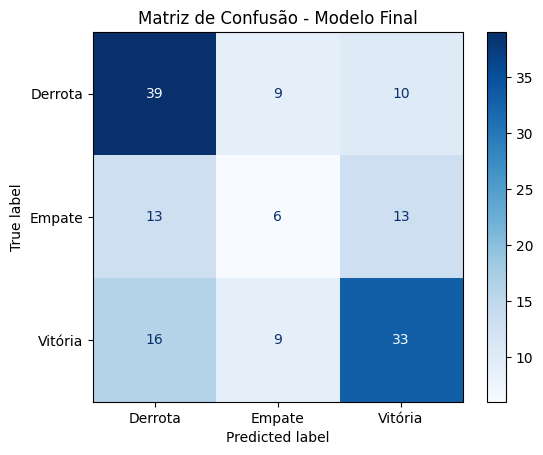

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt


# Matriz de confusão
cm = confusion_matrix(y_test, y_pred, labels=[0, 1, 2])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Derrota', 'Empate', 'Vitória'])

plt.figure(figsize=(6, 5))
disp.plot(cmap='Blues')
plt.title('Matriz de Confusão - Modelo Final')
plt.show()

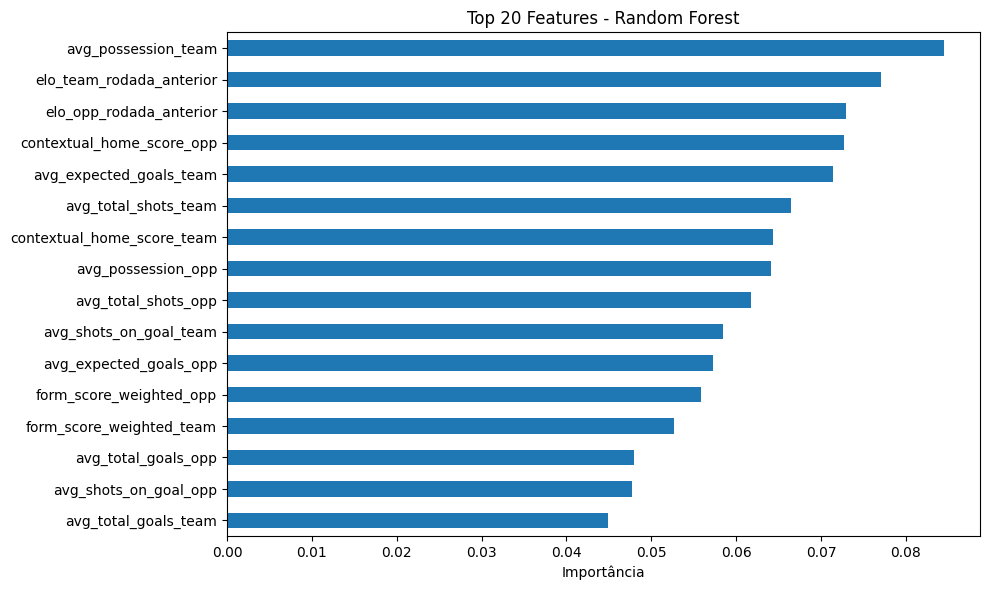

In [411]:
import pandas as pd
import matplotlib.pyplot as plt

# Acessando o modelo Random Forest dentro do pipeline
rf_model = pipeline.named_steps['classifier']

# Acessando os nomes das features após o preprocessor
feature_names = (X.columns)

# Extraindo a importância das features
importances = rf_model.feature_importances_

# Criando gráfico
import pandas as pd
import matplotlib.pyplot as plt

feature_importance = pd.Series(importances, index=feature_names).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
feature_importance.plot(kind='barh')
plt.title('Top 20 Features - Random Forest')
plt.gca().invert_yaxis()
plt.xlabel('Importância')
plt.tight_layout()
plt.show()


In [443]:
joblib.dump(pipeline, 'modelo_random_forest_dupla_entrada.pkl')

['modelo_random_forest_dupla_entrada.pkl']